# A demo ANN code for GMM using NGA-Subduction databse
Sa - Spectral Accelration (g),
Mw- Magnitude of earthquake,
Rhyp- Hypocentral distance,
Vs30- Shear wave veloicty at top 30m,
FM- Fault mechanism,
T- Time period

Reference: Boore, D. M., Stewart, J. P., Seyhan, E., and Atkinson, G. M., 2014. NGA-West2 equations for
predicting PGA, PGV, and 5% damped PSA for shallow crustal earthquakes, Earthquake
Spectra 30, 1057–1085.
***
Sa = f(Mw,Rhyp,Vs30,FM)
***

## 📥 Importing the Dataset

First, install the required libraries and then load the CSV file:

```python

In [5]:
!pip install pandas numpy

import pandas as pd
import numpy as np
# mounting
from google.colab import drive
drive.mount('/content/drive/')
# Load the dataset (update the path if needed)
df = pd.read_csv("/content/drive/MyDrive/AI4DRM/Day 1/Session 1/Data_NGA_subduction.csv")

## 🔍 Preview the Dataset

Use `df.head()` to display the first five rows of the dataset:

In [31]:
#df = pd.read_csv("Data_NGA_subduction.csv")
df.head()

,Mw,Rhyp,Vs30,FM,SA(T=0),SA(T=0.01),SA(T=0.015),SA(T=0.02),SA(T=0.03),SA(T=0.04),...,Sa(T=0.75),Sa(T=0.8),Sa(T=0.9),Sa(T=1),Sa(T=1.2),Sa(T=1.5),Sa(T=2),Sa(T=2.5),Sa(T=3),Sa(T=4)
0,7.96,488.314795,635.0,1,0.002596,0.002600,0.002609,0.002617,0.002650,0.002714,...,0.005298,0.006013,0.004733,0.005812,0.005247,0.004926,0.004117,0.003191,0.003093,0.001290
1,7.96,850.248624,635.0,1,0.002754,0.002780,0.002821,0.002862,0.003020,0.003297,...,0.001926,0.001779,0.001298,0.001379,0.000813,0.000635,0.000563,0.000604,0.000600,0.000427
2,7.78,905.087660,635.0,3,0.000135,0.000135,0.000135,0.000136,0.000136,0.000136,...,0.000308,0.000311,0.000298,0.000362,0.000432,0.000314,0.000228,0.000313,0.000283,0.000228
3,7.28,234.422928,635.0,1,0.029509,0.029530,0.029567,0.029604,0.029802,0.030146,...,0.063084,0.054403,0.046033,0.033333,0.017415,0.012582,0.005988,0.003371,0.002086,0.001502
4,7.21,747.886349,635.0,3,0.000883,0.000884,0.000884,0.000884,0.000885,0.000887,...,0.002693,0.003163,0.003279,0.002598,0.001771,0.001004,0.000908,0.000424,0.000317,0.000394


## 📊 Data Distribution Plots

Below we visualize the distributions of key variables in the dataset:  
**Mw**, **Rhyp**, **Vs30**, and **FM**. To check for the functional form

```python
# Install and import matplotlib

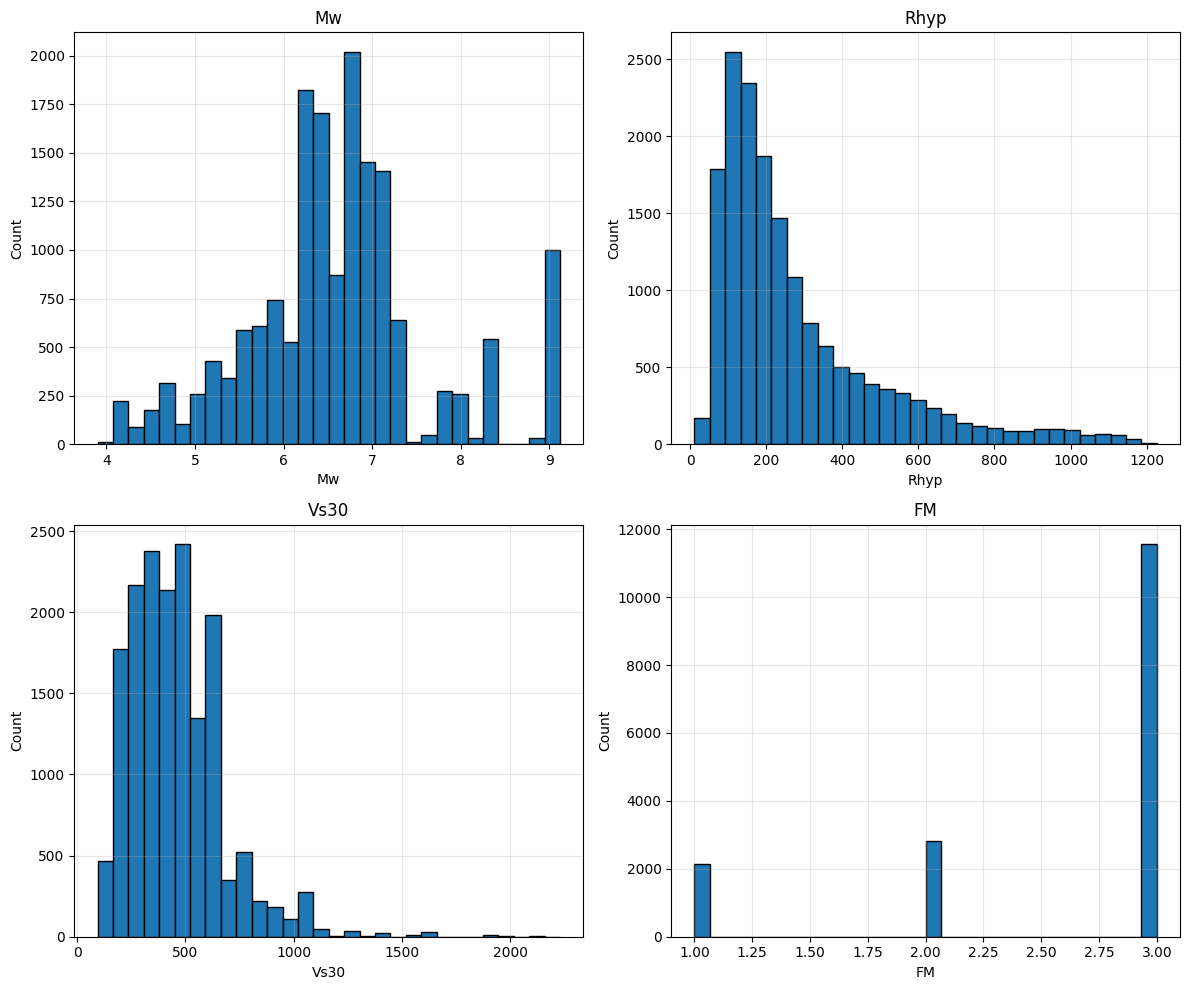

In [32]:
# Data plots
!pip install matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))

# --- Mw ---
plt.subplot(2, 2, 1)
plt.hist(df['Mw'], bins=30, edgecolor='black')
plt.xlabel('Mw')
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.title("Mw")

# --- Rhyp ---
plt.subplot(2, 2, 2)
plt.hist(df['Rhyp'], bins=30, edgecolor='black')
plt.xlabel('Rhyp')
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.title("Rhyp")

# --- Vs30 ---
plt.subplot(2, 2, 3)
plt.hist(df['Vs30'], bins=30, edgecolor='black')
plt.xlabel('Vs30')
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.title("Vs30")

# --- FM ---
plt.subplot(2, 2, 4)
plt.hist(df['FM'], bins=30, edgecolor='black')
plt.xlabel('FM')
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.title("FM")

plt.tight_layout()
plt.show()

## 📊 Data Plot: PGA (SA at T = 0)

The histogram below shows the distribution of **SA(T = 0)**, which corresponds to **PGA**.

***
Sa = f(Mw,Rhyp,Vs30,FM)
***

Text(0.5, 1.0, 'Sa')

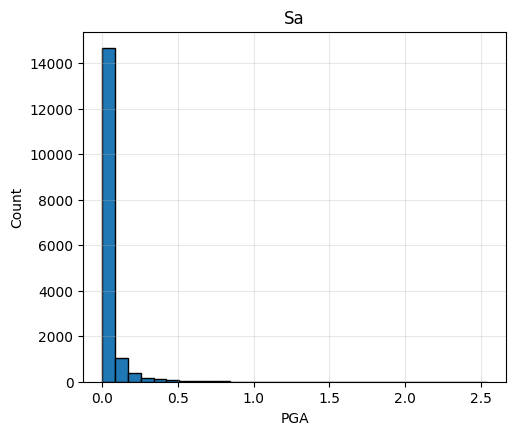

In [33]:
#Data plots
plt.figure(figsize=(12, 10))

# --- Sa ---
plt.subplot(2, 2, 1)
plt.hist(df['SA(T=0)'], bins=30, edgecolor='black')
plt.xlabel('PGA')
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.title("Sa")

## 🧮 Preparing Input and Output Variables

We define the predictor variables (**Mw**, **Rhyp**, **Vs30**, **FM**) and apply log-transforms to **Rhyp** and **Vs30** to stabilize variance and improve model performance.

The response matrix **Y** contains the log₁₀ spectral acceleration values for all SA periods.


In [35]:
# Define inputs and outputs
df["log10_Rhyp"] = np.log10(df["Rhyp"])
df["log10_Vs30"] = np.log10(df["Vs30"])
X = df[["Mw", "log10_Rhyp", "log10_Vs30", "FM"]]   # input matrix
sa_df = df.drop(columns=["Mw", "log10_Rhyp", "log10_Vs30", "FM", "Rhyp", "Vs30"])
Y=np.log10(sa_df)

## 🔀 Train–Validation–Test Split and Data Scaling

We prepare the dataset for machine learning by:

1. **Scaling** inputs and outputs using `MinMaxScaler`  
   (equivalent to MATLAB's `mapminmax`, here mapped to the range **–1 to 1**).

2. **Splitting** the dataset into:
   - 70% training  
   - 15% validation  
   - 15% testing  

This ensures proper training, hyperparameter tuning, and unbiased evaluation.

In [36]:
# Database split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr
# ---- Scaling (mapminmax -> MinMaxScaler range -1 to 1) ----
x_scaler = MinMaxScaler(feature_range=(-1,1))
y_scaler = MinMaxScaler(feature_range=(-1,1))

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(Y)  # shape (n, n_targets)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, train_size=0.70, random_state=42)

n_samples = X.shape[0]
print(f"samples: total={n_samples}, train={len(X_train)}, test={len(X_test)}")

samples: total=16503, train=11552, test=4951


## 🤖 Defining the MLP Neural Network

We configure a **Multi-Layer Perceptron (MLP)** model with:

- One hidden layer  
- Hidden layer size equal to the number of input features  
- `tanh` activation (similar to MATLAB’s *tansig*)  
- `adam` optimizer  
- High iteration limit for stable convergence  

In [37]:
# --- MLP Parameters
hidden_size = X_scaled.shape[1]
mlp = MLPRegressor(hidden_layer_sizes=(hidden_size,),
                   activation='tanh',    # hidden activation like tansig
                   solver='adam',        #  adam optimizer
                   max_iter=2000,
                   tol=1e-6,
                   random_state=42,
                   verbose=False)

## 🏋️‍♂️ Training the MLP and Generating Predictions

We train the MLP neural network using the training dataset.  
After training, predictions are generated for:

- the full dataset  
- the training set  
- the validation set  
- the test set  

All predicted values are inverse-transformed back into the **original log10(Sa)** units.

In [38]:
# ---- Train ----
mlp.fit(X_train, y_train)

# ---- Predict (on full, train, test) and inverse transform to original log10 units ----
y_pred_scaled_full = mlp.predict(X_scaled).reshape(-1, y_scaled.shape[1])
y_pred_full = y_scaler.inverse_transform(y_pred_scaled_full)
y_true_full = Y

y_pred_train = y_scaler.inverse_transform(mlp.predict(X_train).reshape(-1, y_scaled.shape[1]) )
y_true_train = y_scaler.inverse_transform(y_train)

y_pred_test = y_scaler.inverse_transform( mlp.predict(X_test).reshape(-1, y_scaled.shape[1]) )
y_true_test = y_scaler.inverse_transform(y_test)

## 📈 Performance Metrics Function

To evaluate the MLP model, we define a custom function that computes:

- **SD** — Standard deviation of prediction errors  
- **MSR** — Mean squared residual  
- **PP** — Predictive power PP = 1 - MSR/Var(y) 
- **R**

In [39]:
import numpy as np
from scipy.stats import pearsonr

def to_2d_numpy(arr):
    """Ensure arr becomes a 2D numpy array of shape (n_samples, n_targets)."""
    if hasattr(arr, "values"):  # pandas Series/DataFrame
        arr_np = arr.values
    else:
        arr_np = np.asarray(arr)
    if arr_np.ndim == 1:
        arr_np = arr_np.reshape(-1, 1)
    return arr_np

def metrics(y_true, y_pred, target_names=None):
    """
    Compute metrics (SD, MSR, PP, R) per target.
    Prints and returns a list of dicts.
    """
    y_true_np = to_2d_numpy(y_true)
    y_pred_np = to_2d_numpy(y_pred)
    n_targets = y_true_np.shape[1]

    # If no target names provided, auto-generate
    if target_names is None:
        target_names = [f"target_{i}" for i in range(n_targets)]

    results = []

    for j in range(2):
        t = y_true_np[:, j]
        p = y_pred_np[:, j]
        err = p - t

        SD  = np.std(err, ddof=0)
        MSR = np.mean(err**2)
        var_t = np.var(t, ddof=0)
        PP  = 1 - MSR / var_t if var_t != 0 else np.nan
        R   = pearsonr(p, t)[0] if len(t) > 1 else np.nan

        results.append({'SD': SD, 'MSR': MSR, 'PP': PP, 'R': R})

        # ---- PRINT HERE ----
        print(f"\n=== Metrics for {target_names[j]} ===")
        print(f" SD  : {SD:.4e}")
        print(f" MSR : {MSR:.4e}")
        print(f" PP  : {PP:.4f}")
        print(f" R   : {R:.4f}")

    return results

## 📊 Evaluating Model Performance on Train, Validation, Test, and Full Dataset

We use the previously defined `metrics()` function to compute performance statistics  
(**SD, MSR, PP, R**) for each subset of the data:

- Training set  
- Validation set  
- Test set  
- Full dataset  


In [40]:
print("\n======================")
print("=== TRAIN SET METRICS ===")
print("======================")
train_stats = metrics(y_true_train, y_pred_train)

print("\n====================")
print("=== TEST SET METRICS ===")
print("====================")
test_stats  = metrics(y_true_test,  y_pred_test)

print("\n====================")
print("=== FULL DATA METRICS ===")
print("====================")
full_stats  = metrics(y_true_full,  y_pred_full)



=== TRAIN SET METRICS ===

=== Metrics for target_0 ===
 SD  : 4.6059e-01
 MSR : 2.1229e-01
 PP  : 0.7537
 R   : 0.8682

=== Metrics for target_1 ===
 SD  : 4.6138e-01
 MSR : 2.1301e-01
 PP  : 0.7532
 R   : 0.8679

=== TEST SET METRICS ===

=== Metrics for target_0 ===
 SD  : 4.5444e-01
 MSR : 2.0661e-01
 PP  : 0.7665
 R   : 0.8756

=== Metrics for target_1 ===
 SD  : 4.5494e-01
 MSR : 2.0707e-01
 PP  : 0.7662
 R   : 0.8754

=== FULL DATA METRICS ===

=== Metrics for target_0 ===
 SD  : 4.5876e-01
 MSR : 2.1058e-01
 PP  : 0.7576
 R   : 0.8705

=== Metrics for target_1 ===
 SD  : 4.5946e-01
 MSR : 2.1123e-01
 PP  : 0.7571
 R   : 0.8702


## 🔎 Hyperparameter Search: Hidden Layers & Neurons (GridSearchCV)

We perform a grid search over several hidden-layer configurations (1–3 layers with a few neuron choices) to find the best MLP architecture using 3-fold CV and `neg_mean_squared_error` as the scoring metric.

**Notes**
- Grid search can be computationally expensive; reduce `hidden_layer_list` or set `n_jobs=1` if you run into resource limits.
- The script returns the best estimator and evaluates it on train/test/full (inverse-transformed back to original `log10(Sa)` units).
- The best model and scalers are saved with `joblib`

In [45]:
# ===== Hyperparameter search for hidden layers & neurons =====
from sklearn.model_selection import GridSearchCV
import joblib
import time

# --- Ensure X_train, X_val, X_test, y_train, y_val, y_test, X_scaled, y_scaled exist ---
# (The earlier script already creates these via train_test_split + MinMaxScaler.)

# Build candidate hidden layer configurations:
n_inputs = X_scaled.shape[1]
# Example neuron options (you can expand/shrink)
neuron_options = [max(1, n_inputs//2), n_inputs, n_inputs*2]
# Build layer configurations: 1-layer, 2-layer, 3-layer combos
hidden_layer_list = []
for n in neuron_options:
    hidden_layer_list.append((n,))                 # 1 layer
for n1 in neuron_options:
    for n2 in neuron_options:
        hidden_layer_list.append((n1, n2))        # 2 layers
for n1 in neuron_options: 
    for n2 in neuron_options:
        for n3 in neuron_options:
            hidden_layer_list.append((n1, n2, n3))

# optional: remove duplicates and sort by total neurons (nice ordering)
hidden_layer_list = list({h for h in hidden_layer_list})
hidden_layer_list.sort(key=lambda h: (len(h), sum(h)))

print(f"Testing {len(hidden_layer_list)} hidden-layer configurations (example list truncated):")
print(hidden_layer_list[:10], " ...")

# --- Base estimator for GridSearch --- (random state- 19)
base_mlp = MLPRegressor(activation='tanh', solver='adam', max_iter=2000, tol=1e-6,random_state=42)

param_grid = {'hidden_layer_sizes': hidden_layer_list}

# Use neg_mean_squared_error (GridSearch maximizes score, so neg MSE)
gs = GridSearchCV(base_mlp, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

start_time = time.time()
gs.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\nGridSearch done in {elapsed:.1f}s")
print("Best params:", gs.best_params_)
print("Best CV MSE (negative):", gs.best_score_)

# Best estimator
best_model = gs.best_estimator_

# Evaluate best model on test/full (inverse transform back to original log10 units)
def predict_and_inverse(model, X_scaled_subset):
    y_pred_s = model.predict(X_scaled_subset)
    # ensure 2D
    y_pred_s = y_pred_s.reshape(-1, y_scaled.shape[1]) if y_pred_s.ndim == 1 and y_scaled.shape[1] > 1 else np.atleast_2d(y_pred_s).reshape(-1, y_scaled.shape[1])
    return y_scaler.inverse_transform(y_pred_s)

y_pred_train = predict_and_inverse(best_model, X_train)
y_true_train = y_scaler.inverse_transform(y_train)

y_pred_test = predict_and_inverse(best_model, X_test)
y_true_test = y_scaler.inverse_transform(y_test)

y_pred_full = predict_and_inverse(best_model, X_scaled)
y_true_full = y_scaler.inverse_transform(y_scaled)

# Simple metrics helper (reuse or replace with your simple_metrics)
def simple_metrics_np(y_true_np, y_pred_np):
    """
    Both args are numpy arrays shape (n_samples, n_targets)
    returns list of dicts per target
    """
    results = []
    for j in range(y_true_np.shape[1]):
        t = y_true_np[:, j]
        p = y_pred_np[:, j]
        mse = np.mean((p - t)**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(p - t))
        r = pearsonr(p, t)[0] if len(t) > 1 else np.nan
        results.append({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R': r})
    return results

train_stats = simple_metrics_np(y_true_train, y_pred_train)
test_stats  = simple_metrics_np(y_true_test,  y_pred_test)
full_stats  = simple_metrics_np(y_true_full,  y_pred_full)

# Print summary
target_names = (
    ["Sa" + col for col in Y.columns] 
    if isinstance(Y, pd.DataFrame) 
    else [f"Sa{i+1}" for i in range(y_scaled.shape[1])]
)
print("\n=== Best model performance ===")
print("Best hidden_layer_sizes:", gs.best_params_['hidden_layer_sizes'])
for i, name in enumerate(target_names):
    tr = train_stats[i]
    va = val_stats[i]
    te = test_stats[i]
    tot = full_stats[i]
    print(f"\n== {name} ==")
    print(f" Train: MSE={tr['MSE']:.4e}, RMSE={tr['RMSE']:.4e}, MAE={tr['MAE']:.4e}, R={tr['R']:.4f}")
    print(f" Test : MSE={te['MSE']:.4e}, RMSE={te['RMSE']:.4e}, MAE={te['MAE']:.4e}, R={te['R']:.4f}")
    print(f" Full : MSE={tot['MSE']:.4e}, RMSE={tot['RMSE']:.4e}, MAE={tot['MAE']:.4e}, R={tot['R']:.4f}")

# Save best model + scalers
joblib.dump({'model': best_model, 'x_scaler': x_scaler, 'y_scaler': y_scaler, 'input_cols': X.columns.tolist(), 'target_cols': (Y.columns.tolist() if isinstance(Y, pd.DataFrame) else None)}, "best_ann_model.joblib")
print("\nSaved best model to 'best_ann_model.joblib'")

Testing 39 hidden-layer configurations (example list truncated):
[(2,), (4,), (8,), (2, 2), (4, 2), (2, 4), (4, 4), (2, 8), (8, 2), (4, 8)]  ...
Fitting 3 folds for each of 39 candidates, totalling 117 fits

GridSearch done in 32.5s
Best params: {'hidden_layer_sizes': (8, 8)}
Best CV MSE (negative): -0.013542412110574624

=== Best model performance ===
Best hidden_layer_sizes: (8, 8)

== SaSA(T=0) ==
 Train: MSE=1.9587e-01, RMSE=4.4257e-01, MAE=3.4408e-01, R=0.8791
 Test : MSE=1.9269e-01, RMSE=4.3896e-01, MAE=3.3876e-01, R=0.8845
 Full : MSE=1.9491e-01, RMSE=4.4149e-01, MAE=3.4248e-01, R=0.8807

== SaSA(T=0.01) ==
 Train: MSE=1.9628e-01, RMSE=4.4303e-01, MAE=3.4464e-01, R=0.8790
 Test : MSE=1.9295e-01, RMSE=4.3927e-01, MAE=3.3957e-01, R=0.8845
 Full : MSE=1.9528e-01, RMSE=4.4191e-01, MAE=3.4312e-01, R=0.8806

== SaSA(T=0.015) ==
 Train: MSE=1.9703e-01, RMSE=4.4388e-01, MAE=3.4532e-01, R=0.8787
 Test : MSE=1.9371e-01, RMSE=4.4012e-01, MAE=3.4026e-01, R=0.8842
 Full : MSE=1.9603e-01, RMS

## 🧠 Best Neural Network Architecture (From Grid Search)

The following code prints the structure of the best-performing MLP model selected by GridSearchCV:

In [48]:
# Print best model architecture
best_hls = gs.best_params_["hidden_layer_sizes"]

print("\n==============================")
print(" BEST NETWORK ARCHITECTURE")
print("==============================")

print(f"Hidden layer sizes: {best_hls}")
print(f"Number of hidden layers: {len(best_hls)}")
print(f"Neurons per layer: {list(best_hls)}")
print(f"Total hidden neurons: {sum(best_hls)}")



 BEST NETWORK ARCHITECTURE
Hidden layer sizes: (8, 8)
Number of hidden layers: 2
Neurons per layer: [8, 8]
Total hidden neurons: 16


In [49]:
# Load Saved model
import joblib

saved = joblib.load("best_ann_model.joblib")

model = saved['model']
x_scaler = saved['x_scaler']
y_scaler = saved['y_scaler']
input_cols = saved['input_cols']
target_cols = saved['target_cols']

print("Model loaded successfully!")
print("Inputs :", input_cols)
print("Targets:", target_cols)


Model loaded successfully!
Inputs : ['Mw', 'log10_Rhyp', 'log10_Vs30', 'FM']
Targets: ['SA(T=0)', 'SA(T=0.01)', 'SA(T=0.015)', 'SA(T=0.02)', 'SA(T=0.03)', 'SA(T=0.04)', 'SA(T=0.05)', 'SA(T=0.06)', 'SA(T=0.075)', 'Sa(T0.09)', 'Sa(T0.1)', 'Sa(T0.15)', 'Sa(T=0.2)', 'Sa(T=0.3)', 'Sa(T=0.4)', 'Sa(T=0.5)', 'Sa(T=0.6)', 'Sa(T=0.7)', 'Sa(T=0.75)', 'Sa(T=0.8)', 'Sa(T=0.9)', 'Sa(T=1)', 'Sa(T=1.2)', 'Sa(T=1.5)', 'Sa(T=2)', 'Sa(T=2.5)', 'Sa(T=3)', 'Sa(T=4)']


## 📈 Parametric PGA / Sa Plots vs Period

Compute spectral-acceleration (Sa) curves for combinations of magnitude, distance, site (Vs30) and fault mechanism,
using the trained ANN model. The code below builds input rows in the order expected by the saved model (`input_cols`)
and predicts `log10(Sa)` which is converted to Sa (g). It then plots Sa(T) for several Rhyp values.

**Notes**
- If you used `GridSearchCV` earlier, the best estimator is `best_model`. This cell will try to use it.
- Ensure `x_scaler` and `y_scaler` from training are in scope.

Using input order stored in saved model: ['Mw', 'log10_Rhyp', 'log10_Vs30', 'FM']


/home/varun/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/varun/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/varun/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/varun/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/varun/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/varun/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does no

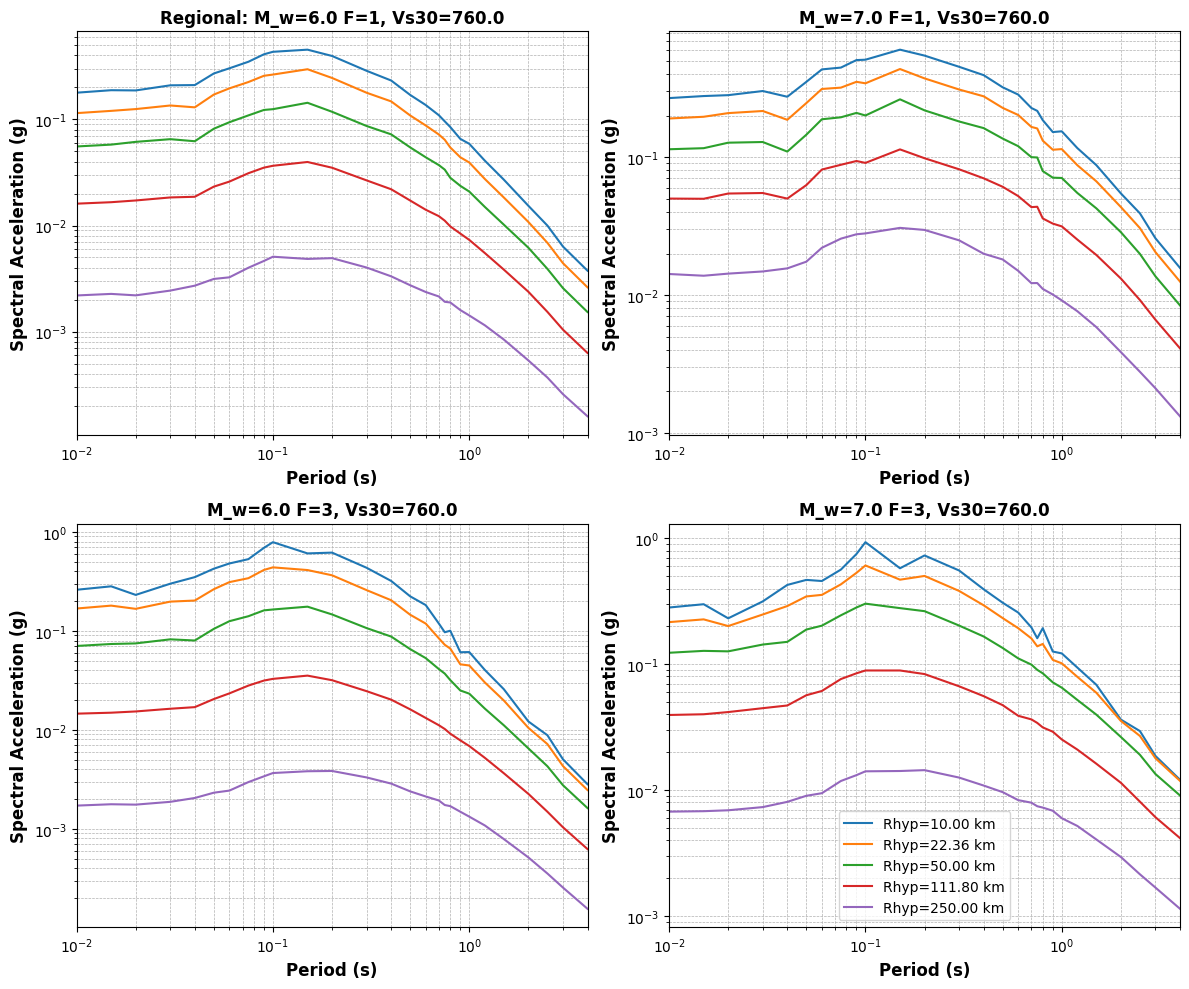

In [50]:
# ----------------- Prepare parammetric plots (debugged) -----------------
import numpy as np
import matplotlib.pyplot as plt

T = np.array([0,0.01,0.015,0.02,0.03,0.04,0.05,0.06,0.075,0.09,0.1,0.15,0.2,
              0.3,0.4,0.5,0.6,0.7,0.75,0.8,0.9,1,1.2,1.5,2,2.5,3,4])
# We'll drop the zero when plotting on log-x
T_pos_mask = T > 0
T_pos = T[T_pos_mask]

M = np.array([6.0, 7.0])
R = np.array([10.0, 22.36, 50.0, 111.80, 250.0])
Vs30 = 760.0
F = np.array([1, 3])   # fault types

# ------------- Input-order builder -------------
# Assume input_cols is available (saved with model). If not, fallback to default.
def safe_log10(x):
    return np.log10(np.maximum(1e-12, np.asarray(x)))

if 'input_cols' in globals() and input_cols is not None:
    print("Using input order stored in saved model:", input_cols)

    def build_input_row(Mw, Rhyp_val, Vs30_val, Fval):
        dd = {
            "Mw": float(Mw),
            "Rhyp": float(Rhyp_val),
            "log10_Rhyp": float(safe_log10(Rhyp_val)),
            "Vs30": float(Vs30_val),
            "log10_Vs30": float(safe_log10(Vs30_val)),
            "FM": float(Fval),
        }
        return np.array([dd[c] if c in dd else 0.0 for c in input_cols], dtype=float)
else:
    print("No input_cols stored; using default ordering: [Mw, log10(Rhyp), log10(Vs30), FM]")
    def build_input_row(Mw, Rhyp_val, Vs30_val, Fval):
        return np.array([Mw, safe_log10(Rhyp_val), safe_log10(Vs30_val), Fval], dtype=float)

# ------------- Prediction wrapper -------------
def model_predict_log10Sa(input_array):
    """
    Returns predicted log10(Sa) as a 2D array shape (n_samples, n_outputs).
    """
    X_in = np.atleast_2d(input_array).astype(float)

    # try scaling if scaler exists
    if 'x_scaler' in globals() and x_scaler is not None:
        try:
            Xs = x_scaler.transform(X_in)
        except Exception:
            Xs = X_in
    else:
        Xs = X_in

    # require 'model' variable in workspace
    if 'model' not in globals():
        raise NameError("No 'model' found. Make sure 'model' refers to your trained estimator (e.g., best_model).")

    y_pred_s = model.predict(Xs)
    # normalize shape to (n_samples, n_outputs)
    y_pred_s = np.atleast_2d(y_pred_s)
    if y_pred_s.shape[0] == 1 and Xs.shape[0] > 1:
        # sklearn sometimes returns shape (1, n_out) for multiple rows; ensure rows match
        y_pred_s = np.repeat(y_pred_s, Xs.shape[0], axis=0)

    # inverse-transform predicted outputs if y_scaler exists
    if 'y_scaler' in globals() and y_scaler is not None:
        try:
            y_pred = y_scaler.inverse_transform(y_pred_s)
        except Exception:
            y_pred = y_pred_s
    else:
        y_pred = y_pred_s

    return y_pred  # shape (n_samples, n_outputs)

# ----------------- Compute PGA1 array -----------------
# shape: (len(F), len(M), len(R), n_periods)
PGA1 = np.zeros((len(F), len(M), len(R), T.size), dtype=float)

for k_idx, fk in enumerate(F):
    for j_idx, mj in enumerate(M):
        for i_idx, ri in enumerate(R):
            # build input for this scalar combination (pass scalar ri, not array R)
            input_row = build_input_row(mj, ri, Vs30, fk)
            pred_log10 = model_predict_log10Sa(input_row)  # (1, n_out) or (1,1)
            pred_flat = pred_log10.ravel()

            # handle scalar output (repeat across periods) or multi-output aligned with T
            if pred_flat.size == 1:
                PGA1[k_idx, j_idx, i_idx, :] = 10.0 ** (pred_flat[0])
            else:
                if pred_flat.size == T.size:
                    PGA1[k_idx, j_idx, i_idx, :] = 10.0 ** pred_flat
                elif pred_flat.size == T_pos.size:
                    # if model returns only for positive T entries, map those
                    tmp = np.zeros(T.size, dtype=float)
                    tmp[T_pos_mask] = 10.0 ** pred_flat
                    PGA1[k_idx, j_idx, i_idx, :] = tmp
                else:
                    raise ValueError(f"Model returned {pred_flat.size} outputs but T has {T.size} periods. Adjust T or model outputs.")

# ----------------- Plotting -----------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

def plot_subplot(ax, pga_matrix, subtitle):
    """
    pga_matrix: shape (n_R, n_periods)
    We plot only T_pos columns (drop T==0)
    """
    pga_to_plot = pga_matrix[:, T_pos_mask]  # drop zero-period column
    for idx in range(pga_to_plot.shape[0]):
        ax.loglog(T_pos, pga_to_plot[idx, :], linewidth=1.5)
    ax.set_xlabel("Period (s)", fontweight="bold", fontsize=12)
    ax.set_ylabel("Spectral Acceleration (g)", fontweight="bold", fontsize=12)
    ax.set_title(subtitle, fontweight="bold", fontsize=12)
    ax.set_xlim([T_pos.min(), 4.0])
    ax.grid(True, which="both", ls="--", lw=0.5)
    ax.tick_params(labelsize=10)

# Subplots
plot_subplot(axes[0], PGA1[0, 0, :, :], f"Regional: M_w={M[0]:.1f} F={F[0]}, Vs30={Vs30}")
plot_subplot(axes[1], PGA1[0, 1, :, :], f"M_w={M[1]:.1f} F={F[0]}, Vs30={Vs30}")
plot_subplot(axes[2], PGA1[1, 0, :, :], f"M_w={M[0]:.1f} F={F[1]}, Vs30={Vs30}")
plot_subplot(axes[3], PGA1[1, 1, :, :], f"M_w={M[1]:.1f} F={F[1]}, Vs30={Vs30}")

legend_labels = [f"Rhyp={r:.2f} km" for r in R]
axes[3].legend(legend_labels, loc="best")

plt.tight_layout()
plt.show()
plt.close(fig)